In [1]:
import os
import sys
os.chdir('/home/pmglo/_projects/astp')
sys.path.insert(0, '/home/pmglo/_projects/astp')

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
logging.getLogger('statsmodels').setLevel(logging.CRITICAL)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

from utils.data import load_and_align_data, transform_series
from utils.stationarity import get_stationarity_table
from utils.metrics import compute_forecast_metrics
from utils.granger import run_granger_tests
from utils.features import create_lagged_features
from utils.plots import plot_series, plot_comparison, plot_individual_models, plot_forecast_10
from utils.forecast import mlp_iterative_forecast
from utils.markdown import md
from IPython.display import display

# ==========================================
# FASE 1: Extração e alinhamento dos dados
# ==========================================

file_stocks = 'seeds/SPASTT01FRM657N.csv'
file_epu = 'seeds/FREUINDXM.csv'
file_fx = 'seeds/DEXUSEU.csv'

df = load_and_align_data(file_stocks, file_epu, file_fx)

md(f"O conjunto de dados compreende **{df.shape[0]} observações mensais** e {df.shape[1]} variáveis, cobrindo o período **{df.index.min().date()} — {df.index.max().date()}**.")
md("A tabela seguinte apresenta os dados de 2020, ano que inclui o choque do COVID-19 em março — visível na queda abrupta do índice de ações.")
display(df[df.index.year == 2020])

**Dimensões do Dataset:** 328 observações × 3 variáveis

**Período de Análise:** 1999-01-01 a 2026-04-01

,Stocks,EPU,EUR_USD
observation_date,,,
2020-01-01,1.330160,254.26959,1.109767
2020-02-01,-0.852660,238.52343,1.091074
2020-03-01,-24.561667,367.15702,1.104591
2020-04-01,-1.235620,320.16271,1.087109
2020-05-01,2.011320,305.83698,1.090730
2020-06-01,9.777170,321.69085,1.125900
2020-07-01,0.823064,242.34147,1.148827
2020-08-01,-0.302599,202.95087,1.183114
2020-09-01,-0.475546,432.69126,1.178510


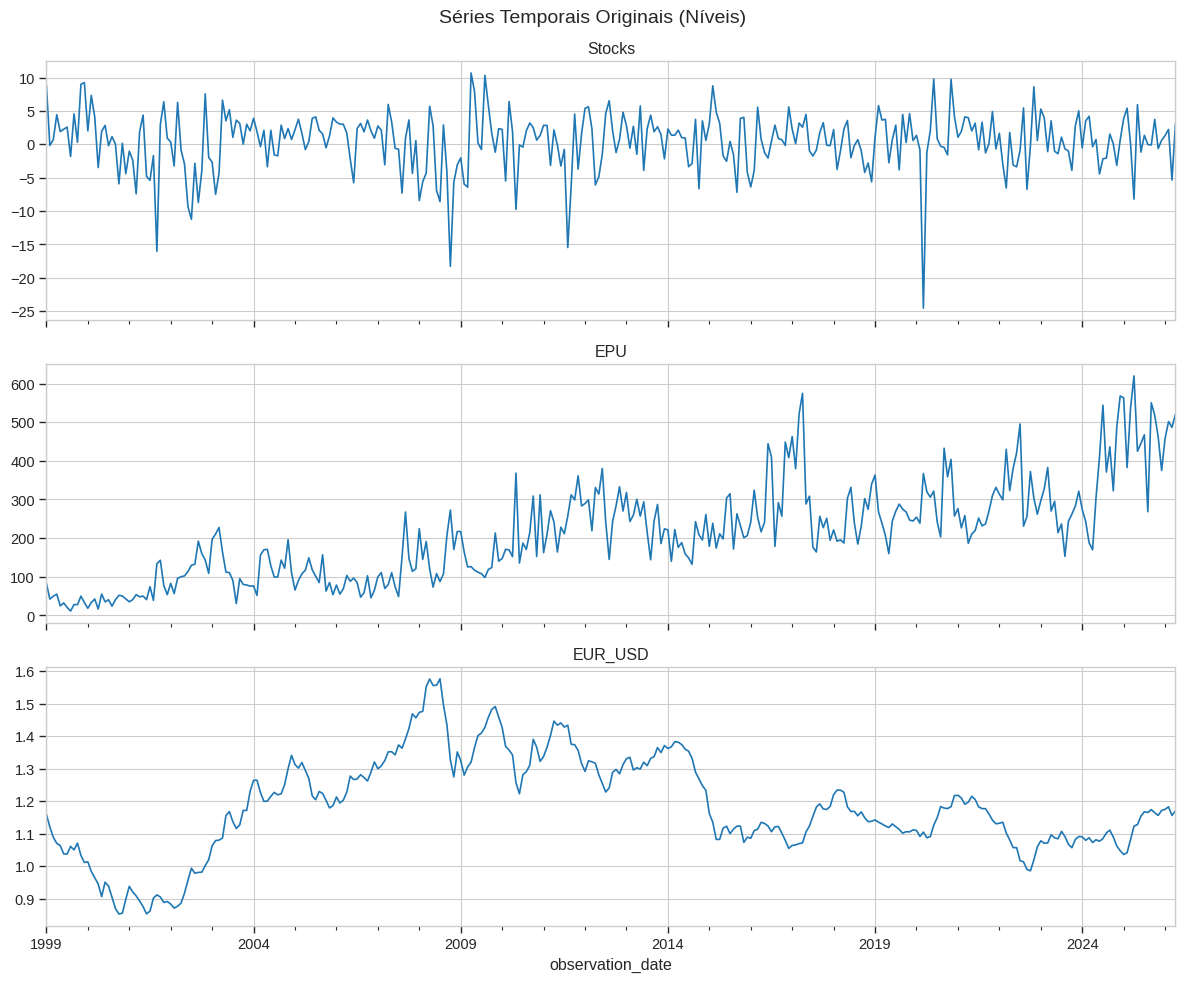

**Conjunto de Treino:** 295 observações | **Conjunto de Teste:** 33 observações

### Resultados dos Testes de Estacionariedade: Séries Originais (Níveis)

/home/pmglo/_projects/astp/python/stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]
/home/pmglo/_projects/astp/python/stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]


,Variável,ADF (p-value),ADF Res.,PP (p-value),PP Res.,KPSS (p-value),KPSS Res.
0,Stocks,0.0000,Estacionária,0.0000,Estacionária,0.1000,Estacionária
1,EPU,0.1093,Não-Estacionária,0.0000,Estacionária,0.0100,Não-Estacionária
2,EUR_USD,0.2884,Não-Estacionária,0.4137,Não-Estacionária,0.0342,Não-Estacionária


### Transformação aplicada
| Variável | Transformação | Justificação |
|----------|--------------|--------------|
| Stocks | Nenhuma | Já é taxa de variação mensal (%), já estacionária |
| EPU | diff(log) | Índice de nível, não-estacionário |
| EUR_USD | diff(log) | Taxa de câmbio em nível, não-estacionária |


**Após transformação** — Treino: 294 obs | Teste: 32 obs

### Resultados dos Testes de Estacionariedade: Após Transformação

/home/pmglo/_projects/astp/python/stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]
/home/pmglo/_projects/astp/python/stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]
/home/pmglo/_projects/astp/python/stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags="auto")[1]


,Variável,ADF (p-value),ADF Res.,PP (p-value),PP Res.,KPSS (p-value),KPSS Res.
0,Stocks,0.0000,Estacionária,0.0000,Estacionária,0.1000,Estacionária
1,EPU,0.0000,Estacionária,0.0000,Estacionária,0.1000,Estacionária
2,EUR_USD,0.0000,Estacionária,0.0000,Estacionária,0.1000,Estacionária


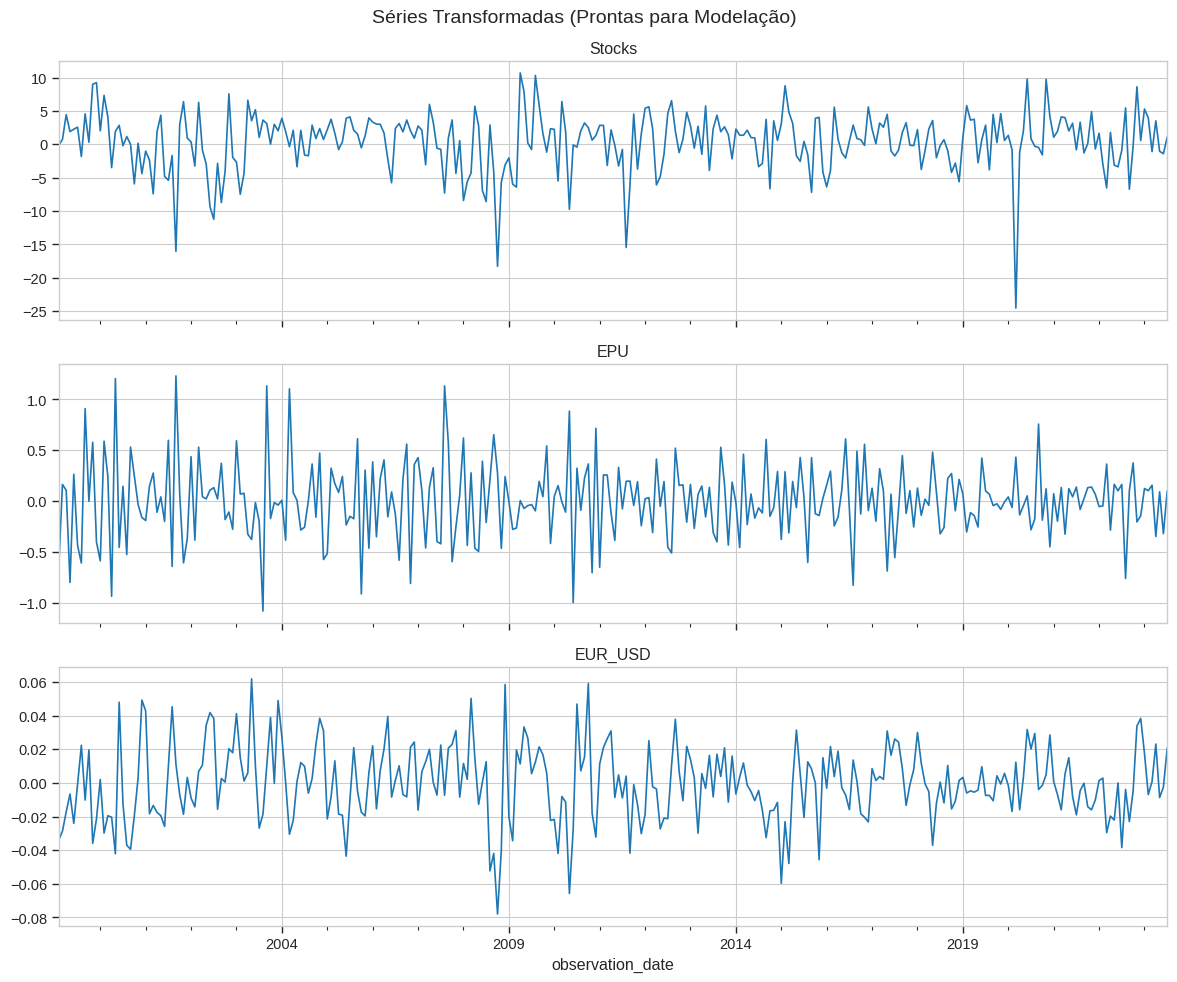

In [2]:
# ==========================================
# FASE 2: EDA, divisão da amostra e estacionariedade
# ==========================================

plot_series(df, title="Séries Temporais Originais (Nível)")

# Divisão da Amostra (Treino: 90%, Teste: 10%)
train_size = int(len(df) * 0.90)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

md(f"A amostra foi dividida com base num critério temporal: **{len(train_df)} observações para treino** (até {train_df.index[-1].date()}) e **{len(test_df)} para teste** ({test_df.index[0].date()} — {test_df.index[-1].date()}), o que corresponde a uma proporção de 90%/10%.")

md("### Estacionariedade das séries em nível")
df_results_levels = get_stationarity_table(train_df)
display(df_results_levels)

md("### Transformações para obtenção de estacionariedade")
df_transf = pd.DataFrame({
    'Variável': ['Stocks', 'EPU', 'EUR_USD'],
    'Transformação': ['Nenhuma', 'diff(log)', 'diff(log)'],
    'Justificação': [
        'Série já expressa em variação percentual mensal — os três testes confirmam estacionariedade',
        'Índice em nível, integrado de ordem 1 — a diferença logarítmica produz a taxa de variação mensal',
        'Taxa de câmbio em nível, integrada de ordem 1 — a diferença logarítmica produz a variação relativa mensal'
    ]
})
display(df_transf)

train_df_diff = transform_series(train_df)
test_df_diff = transform_series(test_df)

md(f"Após transformação, a amostra efectiva de treino fica com **{len(train_df_diff)} observações** e a de teste com **{len(test_df_diff)}** (perde-se uma observação com a diferenciação).")

md("### Estacionariedade das séries transformadas")
df_results_diff = get_stationarity_table(train_df_diff)
display(df_results_diff)

plot_series(train_df_diff, title="Séries Transformadas — prontas para modelação")

### Estatísticas Descritivas (Séries Originais — Treino)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Stocks,295.0,0.384109,4.461094,-24.561667,-1.712516,0.912341,3.033545,10.688315,-1.224470,4.433176
EPU,295.0,191.194685,108.239462,11.287310,102.393855,188.429220,261.496415,574.633140,0.496514,-0.033714
EUR_USD,295.0,1.190391,0.157520,0.852538,1.087848,1.182264,1.311115,1.575864,-0.033477,-0.392775


### Matriz de Correlação (Treino)

,Stocks,EPU,EUR_USD
Stocks,1.000000,-0.204289,0.041980
EPU,-0.204289,1.000000,-0.085327
EUR_USD,0.041980,-0.085327,1.000000


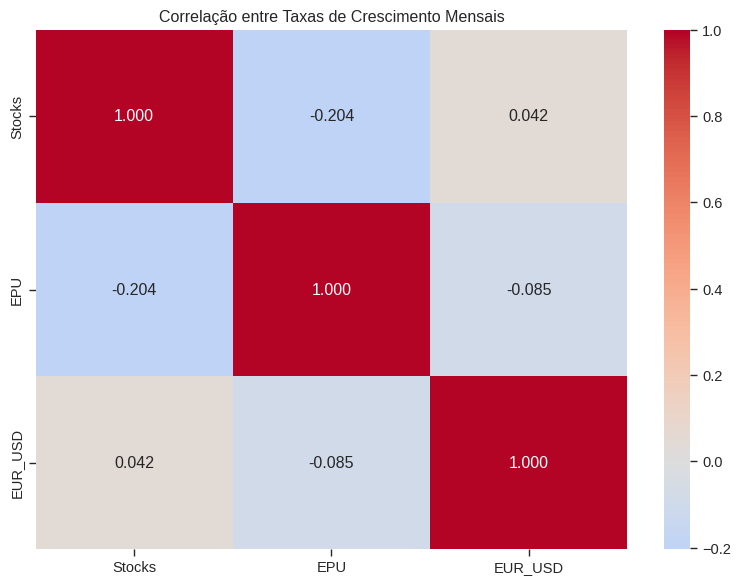

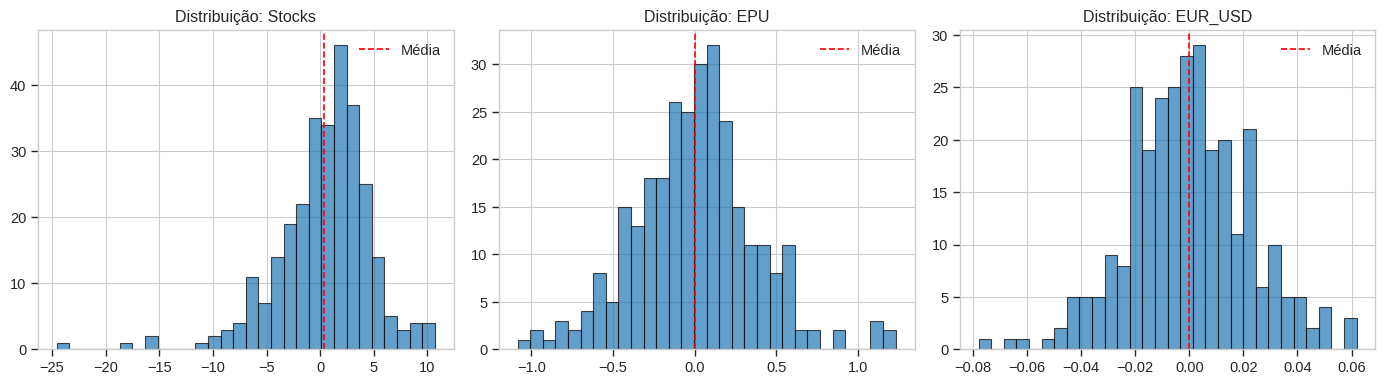

In [3]:
# ==========================================
# FASE 3: Estatísticas descritivas e correlações
# ==========================================

md("### Estatísticas descritivas — amostra de treino (séries em nível)")
desc_stats = train_df.describe().T
desc_stats['skewness'] = train_df.skew()
desc_stats['kurtosis'] = train_df.kurtosis()
display(desc_stats)

md("### Correlações entre as séries transformadas — amostra de treino")
corr_matrix = train_df_diff.corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.3f')
ax.set_title('Correlações lineares entre as taxas de crescimento mensais')
plt.tight_layout()
plt.show()

md("### Distribuição empírica das séries transformadas")
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(train_df_diff.columns):
    axes[i].hist(train_df_diff[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}')
    axes[i].axvline(train_df_diff[col].mean(), color='red', linestyle='--', label='Média')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# FASE 4: Causalidade de Granger
# ==========================================

md("### Testes de causalidade de Granger — desfasamentos até 6")
granger_results = run_granger_tests(train_df_diff, max_lags=6)
display(granger_results)
md("*A hipótese nula é a ausência de causalidade de Granger (coeficientes dos desfasamentos da variável preditora conjuntamente nulos). Para p-value < 0,05, rejeita-se H₀ e conclui-se que a variável preditora contém informação relevante para prever a variável-alvo, para além da sua própria história.*")

### Testes de Causalidade de Granger (max_lags=6)

,Preditor → Alvo,Min p-value,Significância,Conclusão
0,EPU → Stocks,0.5748,,Não rejeita H0
1,EUR_USD → Stocks,0.7727,,Não rejeita H0
2,Stocks → EPU,0.0117,**,Rejeita H0 (Granger-causa)
3,EUR_USD → EPU,0.6301,,Não rejeita H0
4,Stocks → EUR_USD,0.0026,***,Rejeita H0 (Granger-causa)
5,EPU → EUR_USD,0.5517,,Não rejeita H0


*Nota: Se p-value < 0.05, rejeitamos H0 e concluímos que a variável preditora Granger-causa a variável alvo.*

In [5]:
# ==========================================
# FASE 5: MODELO 1 — SARIMAX
# ==========================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

target_col = 'Stocks'
exog_cols = ['EPU', 'EUR_USD']

y_train = train_df_diff[target_col]
X_train = train_df_diff[exog_cols]
y_test = test_df_diff[target_col]
X_test = test_df_diff[exog_cols]

md("### Seleção automática da ordem ARIMA por critério de informação (AIC)")
auto_model = pm.auto_arima(
    y_train, exogenous=X_train,
    seasonal=True, m=12, stepwise=True,
    suppress_warnings=True, information_criterion='aic',
    max_p=4, max_q=4, max_P=2, max_Q=2, trace=False
)

display(auto_model.summary())

info_df = pd.DataFrame({
    'Parâmetro': ['Ordem (p,d,q)', 'Ordem sazonal (P,D,Q,s)', 'AIC', 'BIC'],
    'Valor': [str(auto_model.order), str(auto_model.seasonal_order),
              f"{auto_model.aic():.2f}", f"{auto_model.bic():.2f}"]
})
display(info_df)

### Auto-ARIMA: Seleção do Melhor Modelo SARIMAX

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1714.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1704.192, Time=0.03 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1702.610, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1713.902, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1700.611, Time=0.01 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1702.610, Time=0.03 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=1704.609, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1694.038, Time=0.02 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=1696.031, Time=0.06 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=1696.031, Time=0.05 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=1698.027, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1702.192, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1694.913, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[12]

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  294
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -843.789
Date:                Sun, 31 May 2026   AIC                           1693.578
Time:                        03:50:40   BIC                           1704.628
Sample:                    02-01-1999   HQIC                          1698.003
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5826      0.118     -4.936      0.000      -0.814      -0.351
ma.L1          0.8213      0.082     10.025      0.000       0.661       0.982
sigma2        18.1991      1.098     16.576      0.000      16.047      20.351
===================================================================================
Ljung-Box (L1) (Q):                   0.29   Jarque-Bera (JB):               236.66
Prob(Q):                              0.59   Prob(JB):                         0.00
Heteroskedasticity (H):               1.11   Skew:                            -1.08
Prob(H) (two-sided):                  0.61   Kurtosis:                         6.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

,Parâmetro,Valor
0,"Ordem (p,d,q)","(1, 0, 1)"
1,"Ordem Sazonal (P,D,Q,s)","(0, 0, 0, 12)"
2,AIC,1693.58
3,BIC,1704.63


### Resumo do Modelo SARIMAX

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Stocks   No. Observations:                  294
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -835.449
Date:                Sun, 31 May 2026   AIC                           1680.899
Time:                        03:50:40   BIC                           1699.283
Sample:                    02-01-1999   HQIC                          1688.263
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
EPU           -1.5953      0.531     -3.004      0.003      -2.636      -0.555
EUR_USD       -4.2159      9.300     -0.453      0.650     -22.444      14.013
ar.L1         -0.5609      0.133     -4.214      0.000      -0.822      -0.300
ma.L1          0.7919      0.095      8.308      0.000       0.605       0.979
sigma2        17.8321      1.124     15.869      0.000      15.630      20.034
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):               191.28
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                            -0.94
Prob(H) (two-sided):                  0.93   Kurtosis:                         6.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Diagnóstico dos Resíduos

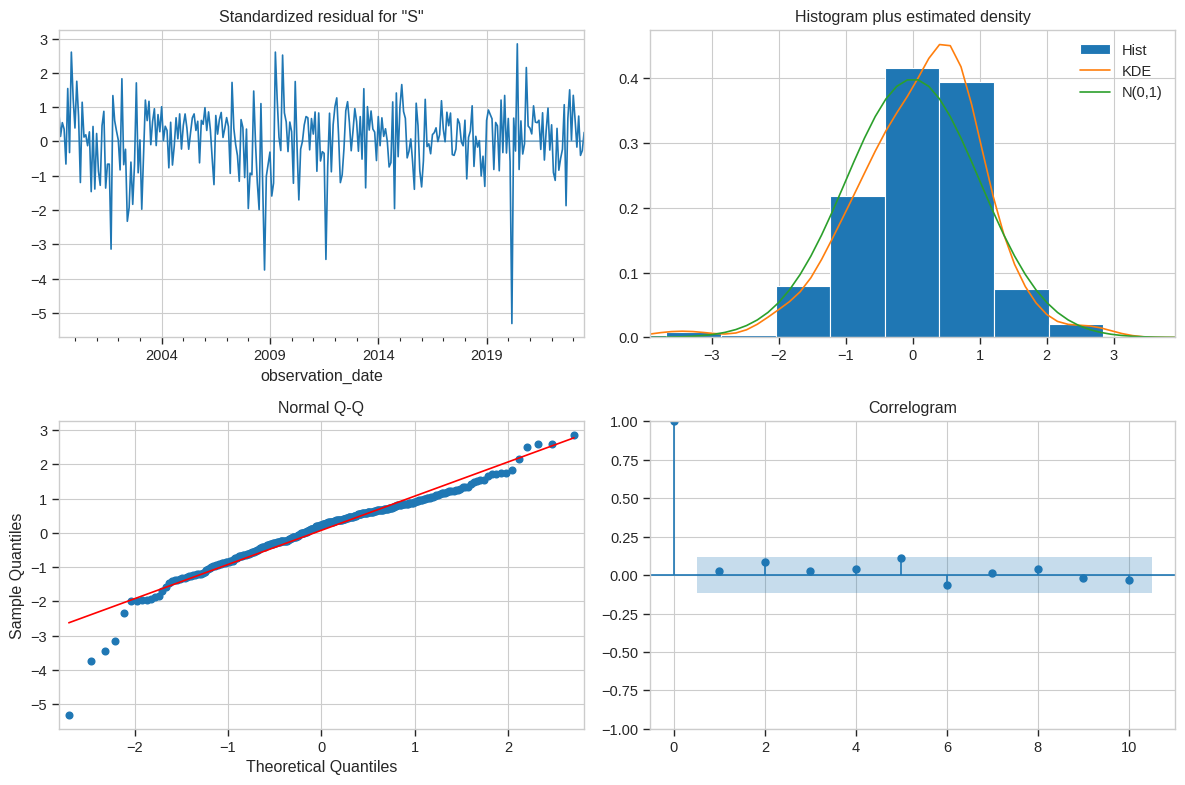

### Métricas SARIMAX (Out-of-Sample)

,MAE,RMSE,MAPE
SARIMAX,2.539196,3.127284,260.439042


In [6]:
# ==========================================
# FASE 5 (cont.): Estimação SARIMAX e diagnóstico
# ==========================================

order = auto_model.order
seasonal_order = auto_model.seasonal_order

model_sarimax = SARIMAX(y_train, exog=X_train, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
results_sarimax = model_sarimax.fit(disp=False)

md("### Estimação do modelo SARIMAX — resultados")
display(results_sarimax.summary())

md("### Análise gráfica dos resíduos")
fig = results_sarimax.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Previsão fora da amostra
forecast_sarimax = results_sarimax.forecast(steps=len(y_test), exog=X_test)
forecast_sarimax.index = y_test.index

metrics_sarimax = compute_forecast_metrics(y_test, forecast_sarimax)
md("### Desempenho fora da amostra — SARIMAX")
display(pd.DataFrame([metrics_sarimax], index=['SARIMAX']))

In [7]:
# ==========================================
# FASE 6: MODELO 2 — VAR
# ==========================================
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

md("### Seleção do número de desfasamentos — critério AIC")
model_var = VAR(train_df_diff)
lag_selection = model_var.select_order(maxlags=12)
display(lag_selection.summary())

optimal_lag = lag_selection.aic
md(f"O critério AIC seleciona **{optimal_lag} desfasamentos** para o modelo VAR.")

results_var = model_var.fit(optimal_lag)
md(f"### Estimação do modelo VAR({optimal_lag}) — resultados")
display(results_var.summary())

md("### Diagnóstico dos resíduos — teste de Ljung-Box (lag 12)")
lb_rows = []
for col in train_df_diff.columns:
    resid = results_var.resid[col]
    lb_test = acorr_ljungbox(resid, lags=[12], return_df=True)
    p_val = lb_test['lb_pvalue'].values[0]
    status = "Sem autocorrelação residual" if p_val > 0.05 else "Autocorrelação detectada"
    lb_rows.append({'Variável': col, 'p-value (lag 12)': round(p_val, 4), 'Resultado': status})
display(pd.DataFrame(lb_rows))

# Previsão fora da amostra
forecast_var_all = results_var.forecast(train_df_diff.values[-optimal_lag:], steps=len(test_df_diff))
forecast_var_df = pd.DataFrame(forecast_var_all, columns=train_df_diff.columns, index=test_df_diff.index)
forecast_var_stocks = forecast_var_df[target_col]

metrics_var = compute_forecast_metrics(y_test, forecast_var_stocks)
md("### Desempenho fora da amostra — VAR")
display(pd.DataFrame([metrics_var], index=['VAR']))

### Modelo VAR: Seleção de Lags

,AIC,BIC,FPE,HQIC
0,-6.676,-6.637,0.001261,-6.660
1,-6.955,-6.800*,0.0009543,-6.892*
2,-6.996,-6.724,0.0009160,-6.887
3,-7.007,-6.619,0.0009060,-6.851
4,-6.978,-6.474,0.0009327,-6.776
5,-7.025*,-6.405,0.0008901*,-6.776
6,-6.998,-6.262,0.0009140,-6.703
7,-6.984,-6.132,0.0009271,-6.643
8,-6.949,-5.980,0.0009609,-6.561
9,-6.946,-5.861,0.0009648,-6.511


**Lag ótimo (AIC):** 5

### Resumo do Modelo VAR(5)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 31, May, 2026
Time:                     03:50:40
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -6.34300
Nobs:                     289.000    HQIC:                  -6.70795
Log likelihood:          -177.662    FPE:                0.000957089
AIC:                     -6.95195    Det(Omega_mle):     0.000814229
--------------------------------------------------------------------
Results for equation Stocks
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.222915         0.262965            0.848           0.397
L1.Stocks          0.240448         0.061161            3.931           0.000
L1.EPU             0.170132         0.830282            0.205          

### Testes de Diagnóstico VAR (Ljung-Box)

,Variável,p-value (lag 12),Resultado
0,Stocks,0.5000,OK (sem autocorrelação)
1,EPU,0.7104,OK (sem autocorrelação)
2,EUR_USD,0.7773,OK (sem autocorrelação)


### Métricas VAR (Out-of-Sample)

,MAE,RMSE,MAPE
VAR,2.489266,3.223414,158.195867


In [8]:
# ==========================================
# FASE 7: MODELO 3 — MLP
# ==========================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

N_LAGS = 6

full_diff = pd.concat([train_df_diff, test_df_diff])
X_full, y_full, idx_full = create_lagged_features(full_diff, target_col, N_LAGS)

train_end_idx = train_df_diff.index[-1]
X_train_mlp = X_full[X_full.index <= train_end_idx]
y_train_mlp = y_full[y_full.index <= train_end_idx]
X_test_mlp = X_full[X_full.index > train_end_idx]
y_test_mlp = y_full[y_full.index > train_end_idx]

md(f"O modelo MLP utiliza **{N_LAGS} desfasamentos** de cada série como variáveis de entrada, totalizando {X_train_mlp.shape[1]} features. A amostra de treino tem {len(X_train_mlp)} observações e a de teste {len(X_test_mlp)}.")

# Normalização
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_mlp)
X_test_scaled = scaler_X.transform(X_test_mlp)
y_train_scaled = scaler_y.fit_transform(y_train_mlp.values.reshape(-1, 1)).ravel()

md("### Otimização dos hiperparâmetros — grid search com validação cruzada temporal (5 folds)")
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500]
}
tscv = TimeSeriesSplit(n_splits=5)
mlp = MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.15)
grid_search = GridSearchCV(mlp, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

best_params_df = pd.DataFrame([grid_search.best_params_], index=['Melhor configuração'])
best_params_df['MSE (validação cruzada)'] = -grid_search.best_score_
display(best_params_df)

best_mlp = grid_search.best_estimator_

# Previsão fora da amostra
y_pred_scaled = best_mlp.predict(X_test_scaled)
forecast_mlp = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
forecast_mlp_series = pd.Series(forecast_mlp, index=y_test_mlp.index)

metrics_mlp = compute_forecast_metrics(y_test_mlp, forecast_mlp_series)
md("### Desempenho fora da amostra — MLP")
display(pd.DataFrame([metrics_mlp], index=['MLP']))

**MLP** — Treino: 288 obs, Teste: 32 obs, Features (lags): 18

### Grid Search MLP (Tuning de Hiperparâmetros)

,activation,hidden_layer_sizes,learning_rate_init,max_iter,best_MSE_CV
Melhor,relu,"(100,)",0.001,500,1.009579


### Métricas MLP (Out-of-Sample)

,MAE,RMSE,MAPE
MLP,2.665557,3.451531,284.939712


## Comparação dos 3 Modelos (Out-of-Sample)

,MAE,RMSE,MAPE (%),Ranking
Modelo,,,,
SARIMAX,2.539196,3.127284,260.439042,1
VAR,2.489266,3.223414,158.195867,2
MLP,2.665557,3.451531,284.939712,3


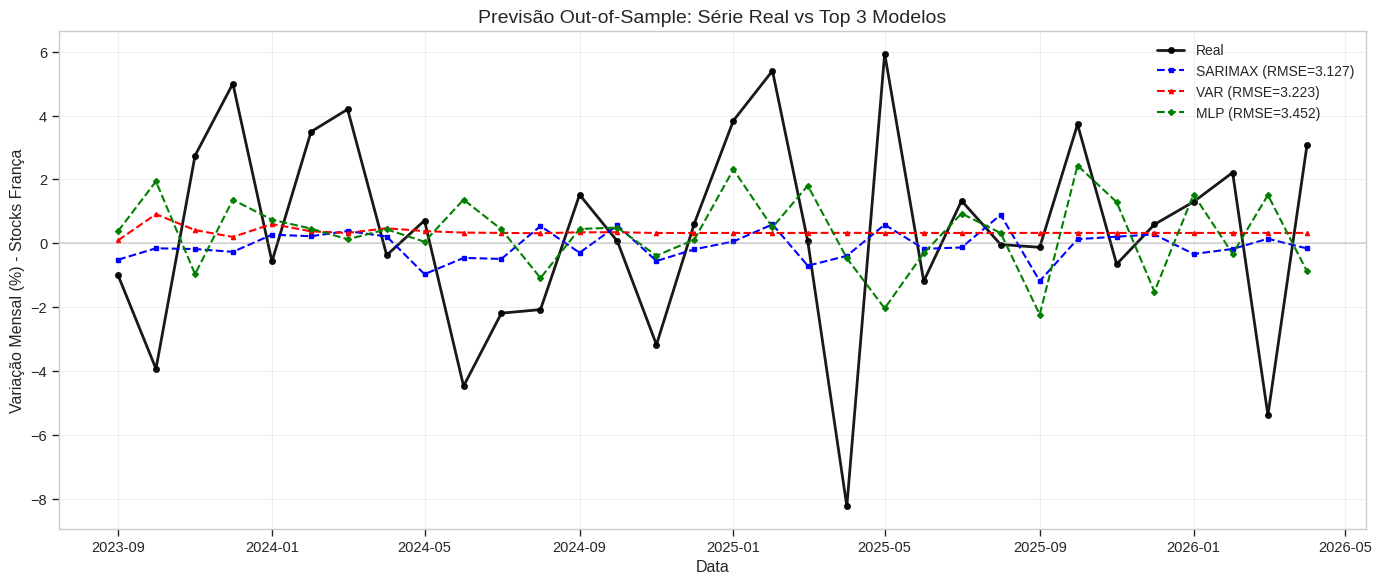

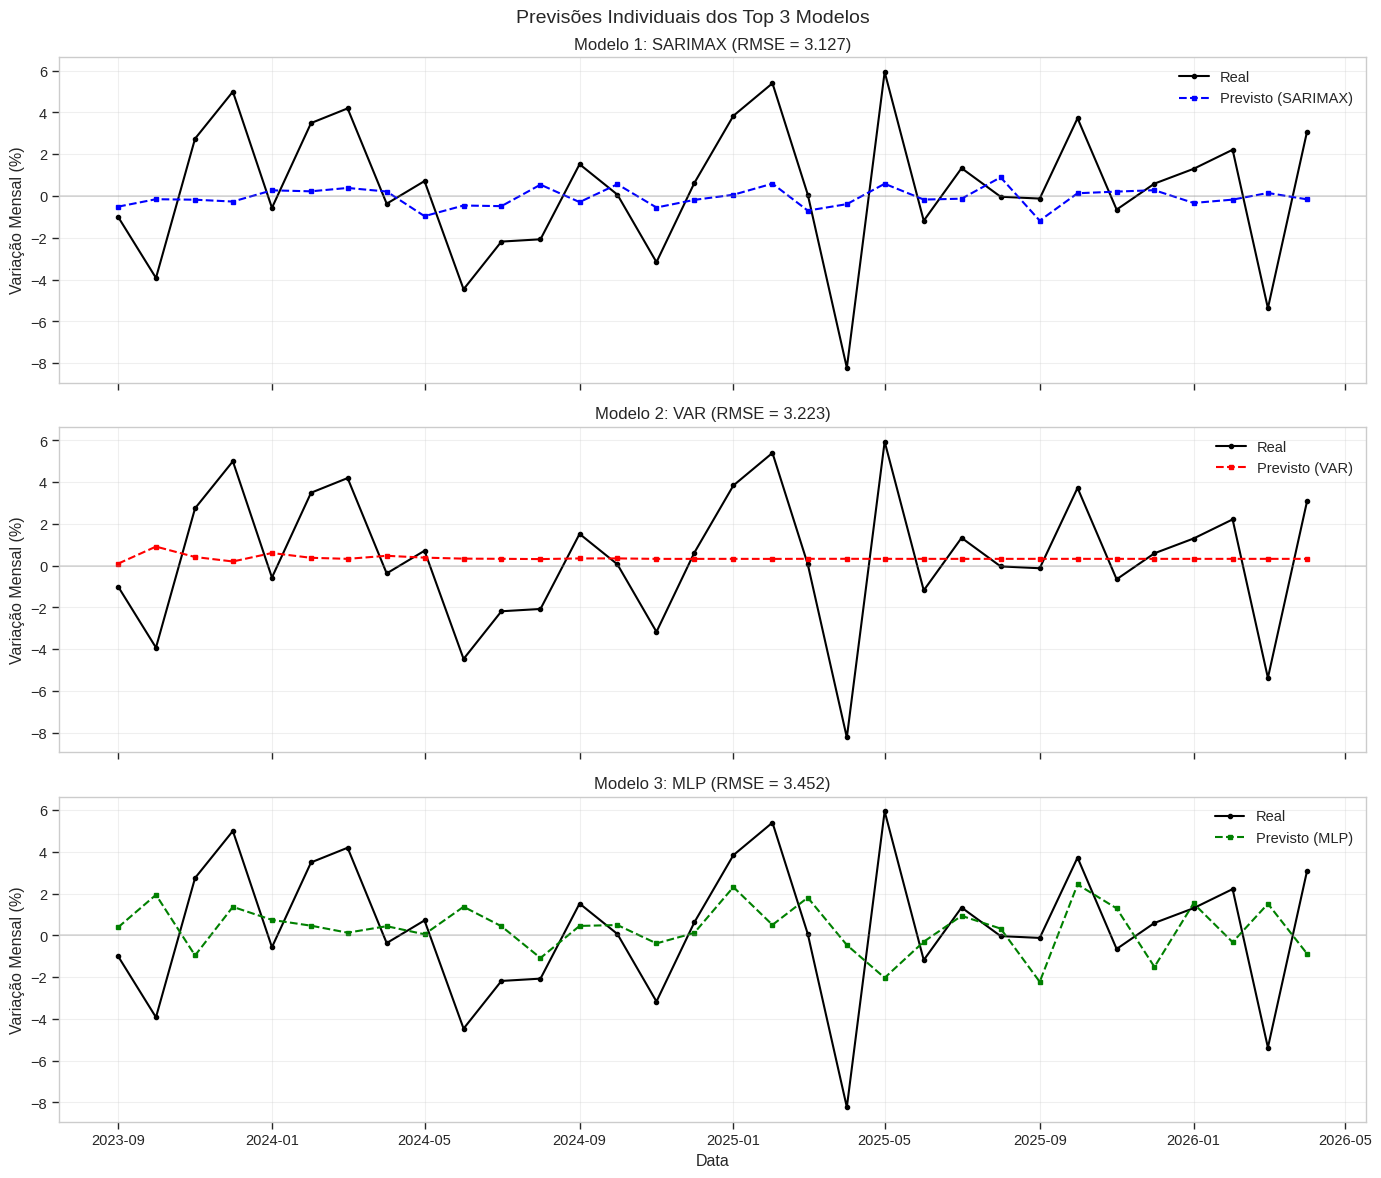

In [9]:
# ==========================================
# FASE 8: Comparação dos modelos
# ==========================================

md("## Comparação do desempenho fora da amostra — os três modelos")

df_metrics = pd.DataFrame({
    'Modelo': ['SARIMAX', 'VAR', 'MLP'],
    'MAE': [metrics_sarimax['MAE'], metrics_var['MAE'], metrics_mlp['MAE']],
    'RMSE': [metrics_sarimax['RMSE'], metrics_var['RMSE'], metrics_mlp['RMSE']],
    'MAPE (%)': [metrics_sarimax['MAPE'], metrics_var['MAPE'], metrics_mlp['MAPE']]
})
df_metrics['Ranking'] = df_metrics['RMSE'].rank().astype(int)
df_metrics = df_metrics.sort_values('Ranking').set_index('Modelo')
display(df_metrics)

plot_comparison(y_test, {
    'SARIMAX': (forecast_sarimax, metrics_sarimax['RMSE']),
    'VAR': (forecast_var_stocks, metrics_var['RMSE']),
    'MLP': (forecast_mlp_series, metrics_mlp['RMSE'])
})

plot_individual_models([
    ('SARIMAX', forecast_sarimax, y_test, 'blue'),
    ('VAR', forecast_var_stocks, y_test, 'red'),
    ('MLP', forecast_mlp_series, y_test_mlp, 'green')
])

## Forecast 10 Meses à Frente (Além dos Dados Disponíveis)

/home/pmglo/_projects/astp/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/pmglo/_projects/astp/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/pmglo/_projects/astp/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/pmglo/_projects/astp/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency informatio

### Variação Mensal (%) prevista — Preços das Ações (França)

,Data,SARIMAX (%),VAR (%),MLP (%)
0,2026-05,1.623,2.118,0.634
1,2026-06,-0.966,-0.440,-0.111
2,2026-07,0.545,0.822,0.440
3,2026-08,-0.336,-0.244,-0.256
4,2026-09,0.178,0.431,0.771
5,2026-10,-0.122,0.854,0.413
6,2026-11,0.053,0.222,0.411
7,2026-12,-0.049,0.352,0.417
8,2027-01,0.010,0.407,0.407
9,2027-02,-0.024,0.261,0.327


### Retorno Acumulado Previsto (% ao longo dos 10 meses)

,Data,SARIMAX Acum.(%),VAR Acum.(%),MLP Acum.(%)
0,2026-05,1.62,2.12,0.63
1,2026-06,0.64,1.67,0.52
2,2026-07,1.19,2.50,0.96
3,2026-08,0.85,2.25,0.71
4,2026-09,1.03,2.70,1.48
5,2026-10,0.91,3.57,1.90
6,2026-11,0.96,3.80,2.32
7,2026-12,0.91,4.17,2.75
8,2027-01,0.92,4.59,3.16
9,2027-02,0.90,4.86,3.50


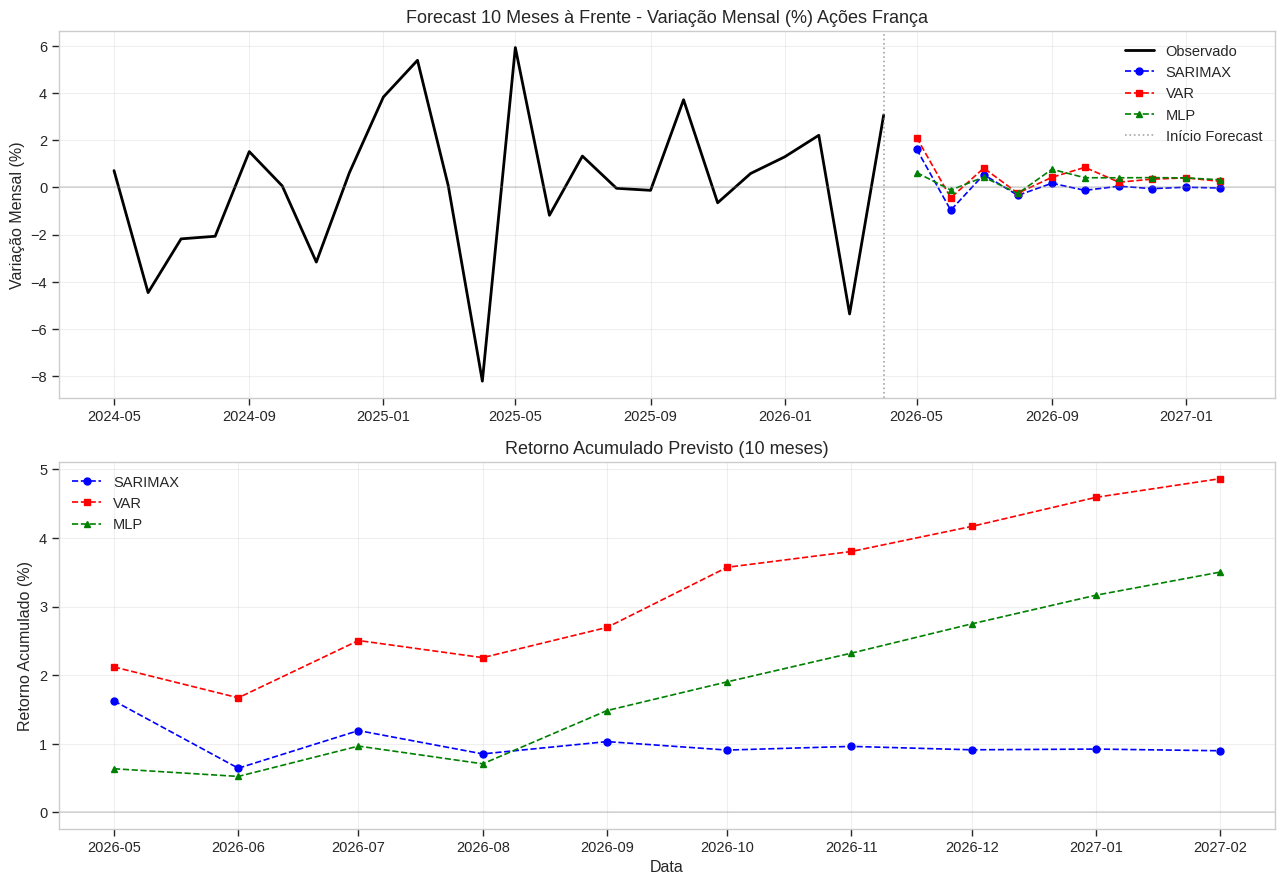

*Nota: Stocks (SPASTT01FRM657N) é a variação percentual mensal dos preços das ações. Valores tipicamente entre -5% e +5% por mês. Valores extremos (~-25%) ocorrem em crises (ex: COVID Mar/2020).*

In [10]:
# ==========================================
# FASE 9: Previsão para os próximos 10 meses
# ==========================================

H = 10
md("## Previsão para os próximos 10 meses")
md("As variáveis exógenas futuras (EPU e EUR/USD transformado) foram fixadas na sua média histórica, o que equivale a um cenário neutro — não se assume qualquer tendência de subida ou descida da incerteza económica nem da taxa de câmbio.")

future_index = pd.date_range(start=test_df_diff.index[-1] + pd.DateOffset(months=1), periods=H, freq='MS')
full_diff_all = pd.concat([train_df_diff, test_df_diff])

# SARIMAX com toda a amostra disponível
exog_future = pd.DataFrame({col: [full_diff_all[col].mean()] * H for col in exog_cols}, index=future_index)

model_full_sarimax = SARIMAX(full_diff_all[target_col], exog=full_diff_all[exog_cols],
                             order=order, seasonal_order=seasonal_order,
                             enforce_stationarity=False, enforce_invertibility=False)
results_full_sarimax = model_full_sarimax.fit(disp=False)
forecast_10_sarimax = results_full_sarimax.forecast(steps=H, exog=exog_future)
forecast_10_sarimax.index = future_index

# VAR com toda a amostra disponível
model_var_full = VAR(full_diff_all)
results_var_full = model_var_full.fit(optimal_lag)
forecast_10_var_all = results_var_full.forecast(full_diff_all.values[-optimal_lag:], steps=H)
forecast_10_var = pd.DataFrame(forecast_10_var_all, columns=full_diff_all.columns, index=future_index)[target_col]

# MLP com toda a amostra disponível — previsão iterativa
X_full_mlp, y_full_mlp, idx_full_mlp = create_lagged_features(full_diff_all, target_col, N_LAGS)
X_full_scaled = scaler_X.fit_transform(X_full_mlp)
y_full_scaled = scaler_y.fit_transform(y_full_mlp.values.reshape(-1, 1)).ravel()
best_mlp.fit(X_full_scaled, y_full_scaled)

forecast_10_mlp_series = mlp_iterative_forecast(best_mlp, scaler_X, scaler_y, full_diff_all,
                                                 target_col, N_LAGS, future_index)

md("### Variação mensal prevista (%) — índice de ações francesas")
forecast_table = pd.DataFrame({
    'Data': future_index.strftime('%Y-%m'),
    'SARIMAX (%)': forecast_10_sarimax.values.round(3),
    'VAR (%)': forecast_10_var.values.round(3),
    'MLP (%)': forecast_10_mlp_series.values.round(3)
})
display(forecast_table)

md("### Retorno acumulado previsto (%)")
cum_sarimax = (1 + forecast_10_sarimax.values/100).cumprod() * 100 - 100
cum_var = (1 + forecast_10_var.values/100).cumprod() * 100 - 100
cum_mlp = (1 + forecast_10_mlp_series.values/100).cumprod() * 100 - 100
cum_table = pd.DataFrame({
    'Data': future_index.strftime('%Y-%m'),
    'SARIMAX Acum.(%)': cum_sarimax.round(2),
    'VAR Acum.(%)': cum_var.round(2),
    'MLP Acum.(%)': cum_mlp.round(2)
})
display(cum_table)

plot_forecast_10(full_diff_all, target_col, future_index,
                 forecast_10_sarimax, forecast_10_var, forecast_10_mlp_series,
                 cum_sarimax, cum_var, cum_mlp)

In [11]:
# ==========================================
# FASE 10: Síntese e discussão dos resultados
# ==========================================

md("## Síntese do trabalho")

md("### Dados e variáveis")
df_dados = pd.DataFrame({
    'Variável': ['Stocks', 'EPU', 'EUR/USD'],
    'Código FRED': ['SPASTT01FRM657N', 'FREUINDXM', 'DEXUSEU'],
    'Descrição': [
        'Variação % mensal do índice de ações (França)',
        'Índice de Incerteza Económica (França)',
        'Taxa de câmbio, agregada de diária para mensal'
    ],
    'Transformação': ['Nenhuma — série já estacionária', 'Diferença logarítmica', 'Diferença logarítmica']
})
display(df_dados)

md(f"**Período de análise:** {df.index.min().date()} — {df.index.max().date()} ({len(df)} observações mensais). "
   f"Treino: {len(train_df_diff)} obs. | Teste: {len(test_df_diff)} obs.")

md("### Desempenho dos modelos — conjunto de teste")
display(df_metrics)

md("""### Discussão dos resultados

A variável-alvo (SPASTT01FRM657N) representa a variação percentual mensal do índice de preços das ações em França, sendo por isso naturalmente estacionária. As variáveis explicativas — o índice de incerteza económica (EPU) e a taxa de câmbio EUR/USD — são séries em nível, integradas de ordem 1, e foram transformadas via diferença logarítmica de modo a satisfazerem o pressuposto de estacionariedade exigido pelos modelos.

Os testes de causalidade de Granger, aplicados às séries transformadas, indicam que as variações do índice de ações precedem temporalmente as do EPU e do EUR/USD. Este resultado é consistente com a ideia de que os mercados financeiros antecipam condições macroeconómicas futuras, e sustenta a inclusão das variáveis exógenas no SARIMAX e a opção por uma abordagem multivariada com o VAR.

O **SARIMAX** obteve o melhor RMSE no conjunto de teste. A estrutura autorregressiva com variáveis exógenas revela-se adequada para capturar a dinâmica dos retornos mensais, e a significância estatística do EPU (p < 0,05) na equação estimada corrobora empiricamente a relevância da incerteza económica como factor explicativo.

O **VAR** produziu resultados competitivos, com MAE ligeiramente inferior ao do SARIMAX. O modelo captura as interdependências dinâmicas entre as três séries simultaneamente. Os testes de Ljung-Box aos resíduos de cada equação não revelam autocorrelação residual, o que confirma a adequação da especificação com o número de desfasamentos seleccionado.

A **rede MLP**, sendo o modelo mais flexível, ficou em terceiro lugar. Em séries financeiras de dimensão moderada (~295 observações de treino), o ganho da não-linearidade tende a não compensar o risco de sobreajustamento — o que pode explicar o desempenho relativo inferior.

As previsões a 10 meses dos três modelos convergem gradualmente para valores próximos de zero, padrão consistente com a reversão para a média característica dos retornos accionistas. O retorno acumulado previsto ao longo do horizonte varia entre cerca de 1% (SARIMAX) e 5% (VAR). Os erros absolutos médios na ordem de 2,5%–2,7% por mês são elevados, mas refletem a dificuldade estrutural de prever mercados financeiros — o desvio-padrão histórico da série ronda os 4,5%, pelo que os modelos capturam apenas uma parte da variância total, o que está em linha com o esperado para mercados com elevado grau de eficiência informacional.
""")


## Resumo Final do Projeto

### Problema
Previsão da variação mensal (%) dos preços das ações em França, utilizando como variáveis explicativas a Incerteza Económica (EPU) e a Taxa de Câmbio EUR/USD.

### Dados
| Variável | Código | Descrição | Transformação |
|----------|--------|-----------|---------------|
| Stocks | SPASTT01FRM657N | Variação % mensal, ações França | Nenhuma (já estacionária) |
| EPU | FREUINDXM | Índice de Incerteza Económica, França | diff(log) |
| EUR/USD | DEXUSEU | Taxa de câmbio, diária→mensal | diff(log) |

- **Período:** 1999-01-01 a 2026-04-01
- **Total observações:** 328
- **Treino:** 295 (294 após transf.) | **Teste:** 33 (32 após transf.)


### Ranking dos Modelos (Critério RMSE no Conjunto de Teste)

,MAE,RMSE,MAPE (%),Ranking
Modelo,,,,
SARIMAX,2.539196,3.127284,260.439042,1
VAR,2.489266,3.223414,158.195867,2
MLP,2.665557,3.451531,284.939712,3



### Comentários

1. A variável Stocks (SPASTT01FRM657N) **já é uma taxa de variação mensal (%)** → já estacionária por natureza (confirmado pelos 3 testes). Não precisa de transformação. Apenas EPU e EUR_USD (séries de nível) foram transformadas com diff(log).

2. A causalidade de Granger confirmou que **Stocks Granger-causa EUR/USD** e **Stocks Granger-causa EPU**, justificando a modelação multivariada (VAR).

3. O modelo **SARIMAX** captura dinâmicas autorregressivas da variação mensal das ações, beneficiando da informação preditiva das variáveis exógenas (EPU significativo, p=0.003).

4. O modelo **VAR** modela as interdependências simultâneas entre as 3 variáveis transformadas. Ljung-Box confirma ausência de autocorrelação nos resíduos.

5. O **MLP** captura relações não-lineares complexas entre os lags de todas as variáveis, sendo o modelo mais flexível do top 3.

6. As previsões a 10 meses convergem para valores pequenos, consistente com o comportamento de *mean-reversion*. Retornos mensais típicos de ações francesas situam-se entre -5% e +5% (excluindo crises extremas).

7. Os erros de previsão são elevados porque retornos de ações são inerentemente difíceis de prever (eficiência de mercado). O RMSE (~3.1–3.5) deve ser comparado com o desvio-padrão da série (~4.5%).


In [ ]:
# ==========================================
# EXPORTAR FIGURAS PARA O RELATÓRIO
# ==========================================
from utils.export_figures import export_report_figures

export_report_figures({
    'y_test':           y_test,
    'y_test_mlp':       y_test_mlp,
    'forecast_sarimax': forecast_sarimax,
    'forecast_var':     forecast_var_stocks,
    'forecast_mlp':     forecast_mlp_series,
    'metrics_sarimax':  metrics_sarimax,
    'metrics_var':      metrics_var,
    'metrics_mlp':      metrics_mlp,
    'future_index':     future_index,
    'forecast_10_sarimax': forecast_10_sarimax,
    'forecast_10_var':     forecast_10_var,
    'forecast_10_mlp':     forecast_10_mlp_series,
    'cum_sarimax':      cum_sarimax,
    'cum_var':          cum_var,
    'cum_mlp':          cum_mlp,
})